In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [9]:
barrios=gpd.read_file('./datasets/datasets_datos_georreferenciados/barrios.gml')
barrios.head(2)

,gml_id,coordinates,MSLINK,BARRIO,OBSERVACIO,geometry
0,barrios.1,"-60.689926,-32.964951 -60.688644,-32.964122",28,VICTORIA WALSH,Mod Lím Or,"POLYGON ((-60.68993 -32.96495, -60.68973 -32.9..."
1,barrios.2,"-60.664275,-32.997578 -60.662190,-32.996287",38,14 DE OCTUBRE,BARRIO DEL,"POLYGON ((-60.66428 -32.99669, -60.66418 -32.9..."


In [10]:
barrios.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   gml_id       51 non-null     object  
 1   coordinates  51 non-null     object  
 2   MSLINK       51 non-null     int32   
 3   BARRIO       51 non-null     object  
 4   OBSERVACIO   51 non-null     object  
 5   geometry     51 non-null     geometry
dtypes: geometry(1), int32(1), object(4)
memory usage: 2.3+ KB


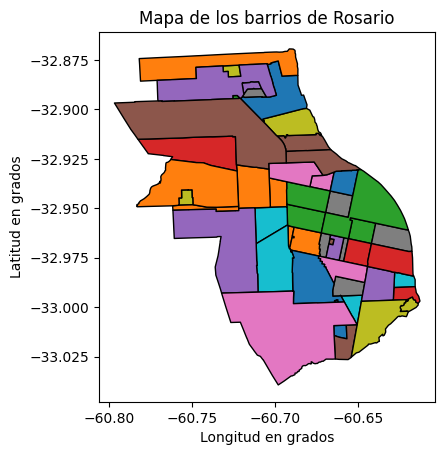

In [13]:
barrios.plot(edgecolor='black', column='BARRIO')
plt.title('Mapa de los barrios de Rosario')
plt.xlabel('Longitud en grados')
plt.ylabel('Latitud en grados')
plt.show()

In [14]:
barrios.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## Encontrar barrio con mayor superficie

In [17]:
#encontrar barrio con mayor superficie
barrios.area.head(5)

C:\Users\Dark7 120gb\AppData\Local\Temp\ipykernel_6576\1920164182.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  barrios.area.head(5)


0    8.510350e-07
1    2.157878e-06
2    5.257126e-06
3    7.147992e-06
4    2.508745e-05
dtype: float64

In [18]:
#convertimos a CRS
barrios_trans=barrios.to_crs(epsg=5347) #sistema POSGAR 07 - Faja 5 zona donde esta rosario

In [19]:
barrios_trans.crs

<Projected CRS: EPSG:5347>
Name: POSGAR 2007 / Argentina 5
Axis Info [cartesian]:
- X[north]: Northing (metre)
- Y[east]: Easting (metre)
Area of Use:
- name: Argentina - between 61°30'W and 58°30'W onshore.
- bounds: (-61.51, -39.06, -58.5, -23.37)
Coordinate Operation:
- name: Argentina zone 5
- method: Transverse Mercator
Datum: Posiciones Geodesicas Argentinas 2007
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [21]:
#calculamos superficie cada barrio
barrios_trans['area_m2']=barrios_trans.area
barrios_trans['area_km2']=barrios_trans['area_m2']/1e6

In [25]:
#Buscamos barrio con mayor superficie
barrios_ordenados=barrios_trans.sort_values('area_km2',ascending=False).head(5)

In [26]:
barrio_mayor_sup=barrios_ordenados.iloc[[0]]
barrio_mayor_sup

,gml_id,coordinates,MSLINK,BARRIO,OBSERVACIO,geometry,area_m2,area_km2
50,barrios.51,"-60.732331,-33.039345 -60.650593,-32.991879",27,MERCEDES DE SAN MARTIN,Mod Lím Or,"POLYGON ((5431555.207 6349765.98, 5431810.969 ...",2.234854e+07,22.348537


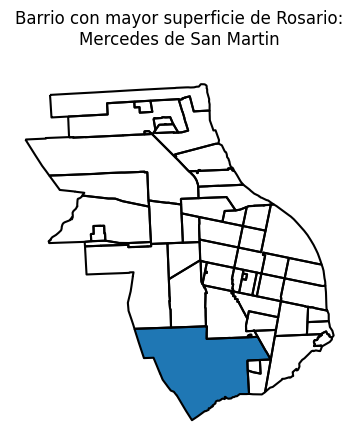

In [32]:
grafico_base=barrios_trans.boundary.plot(edgecolor='black')
barrio_mayor_sup.plot(ax=grafico_base)
plt.title('Barrio con mayor superficie de Rosario:\nMercedes de San Martin')
#plt.xlabel('Longitud en grados')
#plt.ylabel('Latitud en grados')
plt.axis('off')
plt.show()

In [33]:
#se puede hacer con idxmax sino
barrios_trans['area_km2'].idxmax()

50

In [34]:
barrios_trans.iloc[50]

gml_id                                                barrios.51
coordinates          -60.732331,-33.039345 -60.650593,-32.991879
MSLINK                                                        27
BARRIO                                    MERCEDES DE SAN MARTIN
OBSERVACIO                                            Mod Lím Or
geometry       POLYGON ((5431555.207442 6349765.9797554035, 5...
area_m2                                          22348536.915326
area_km2                                               22.348537
Name: 50, dtype: object

# DATASET CENTRO DE SALUD

In [35]:
salud=gpd.read_file('./datasets/datasets_datos_georreferenciados/geo_salud.gml')
salud.head()

,fid,id,name,codigo_calle,calle,altura,bis,direccion,etiquetas,subtipo,...,titular,estado,tipo_geometria,ultima_actualizacion,contactos,atencion,descripcion,piso,multimedia,geometry
0,F0,1220,Hospital Provincial,21950,ALEM LEANDRO N,1450,0,ALEM LEANDRO N 1450,"Salud, Datos útiles",LUGAR,...,Provincial,Publicado,Punto,01/08/2017 09:35,Teléfono: 4801402.,None,None,None,None,POINT (-60.63051 -32.95626)
1,F1,1221,Hospital Provincial del Centenario,93050,URQUIZA GRAL. JUSTO JOSE,3101,0,URQUIZA GRAL. JUSTO JOSE 3101,"Salud, Datos útiles",LUGAR,...,Provincial,Publicado,Punto,01/08/2017 09:35,Teléfono: 4724643 Conmutador 4724649/ 4804521.,None,None,None,None,POINT (-60.66491 -32.93815)
2,F2,1792,Policlínico PAMI I,87300,SARMIENTO DOMINGO FAUSTIN,373,0,SARMIENTO DOMINGO FAUSTIN 373,"Salud, Datos útiles",LUGAR,...,Nacional,Publicado,Punto,01/08/2017 09:35,Teléfono: 4803520 al 30.,None,None,None,None,POINT (-60.63683 -32.94157)
3,F3,1793,Policlínico PAMI II,72900,OLIVE AUGUSTO J,1159,0,OLIVE AUGUSTO J 1159,"Salud, Datos útiles",LUGAR,...,Nacional,Publicado,Punto,01/08/2017 09:35,Teléfono: 4803560 al 73.,None,None,None,None,POINT (-60.67993 -32.91301)
4,F4,3175,Laboratorio de Especialidades Medicinales (LEM),61600,LAVALLE GENERAL JUAN,370,0,LAVALLE GENERAL JUAN 370,"Salud, Datos útiles",LUGAR,...,Municipal,Publicado,Punto,27/08/2019 10:41,Web: http://www.lemrosario.com.ar. Teléfono: 4...,Lunes a viernes de 09:00 a 13:00,None,None,None,POINT (-60.67665 -32.93432)
